# Laboratotio 1

En este laboratorio elaborado por Juan Esteban Piñeros Barrera - 202412232 y Julian Ramos, vamos a trabajar el problema que enfrenta AlpesPlanck, para esto vamos a usar un modelo de regresion lineal a los datos proporcionados por la organizacion. En primer lugar vamos a importar todas las librerias que vamos a estar utilizando en este proceso.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from statsmodels.formula.api import ols

from statsmodels.stats.diagnostic import linear_rainbow
from scipy.stats import ttest_1samp
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import shapiro

Importamos todas estas librerias basandonos en las practicas del curso, sobretodo la practica 4.2 que consideramos que es la que contiene todo lo relevante para nuestro laboratorio, aunque si es necesario mas adelante importaremos librerias que nos puedan ser utiles

## 1. Conversion y analisis de datos

En esta seccion vamos a transformar los datos que recibimos en forma de .csv en un DataFrame para poder usarlos y hacer sus respectivos analisis que van a marcar nuestras acciones mas adelante

In [2]:
datos_test = pd.read_csv('data/Datos_Lab1.csv', sep=',')
data = datos_test.copy()
data.head()

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
0,2009-01-01,999.1456,996.50,1000.87,1.3993,0.910860,0.875000,94.8,1.7650,0.7786,...,-0.3618,-0.0223,183.5308,143.0,2009.0,1.0,invierno,January,S,-2.12
1,2009-01-02,999.6006,997.93,1002.65,1.5039,0.920868,86.600000,96.3,2.7588,1.4195,...,0.4267,0.3689,40.8436,144.0,2009.0,2.0,invierno,JULY,NE,-0.82
2,2009-01-03,998.5486,993.05,1002.49,3.1304,76.458100,48.390000,93.9,15.1796,1.2509,...,-0.6993,-0.5268,216.9916,144.0,2009.0,3.0,invierno,January,SO,-0.63
3,2009-01-04,988.5107,985.12,992.93,2.3223,89.417400,97.946704,NaN,4.4904,1.7204,...,-1.1268,-1.0413,222.7419,144.0,2009.0,4.0,invierno,JANUARY,SO,-1.44
4,2009-01-05,990.4057,NaN,997.54,4.2315,86.260400,74.600000,93.2,5.3922,3.8003,...,2.6275,0.2874,6.2418,NaN,2009.0,5.0,East,January,N,-10.88


Muy bien, ya cargado el DataFrame vamos a verificar como se ven los datos para tener una idea clara de con que vamos a estar trabajando

En primer lugar vamos a ver como se ven 10 datos aleatorios de nuestro dataframe

In [3]:
display(data.sample(10))

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
1090,2011-12-27,1008.0031,1006.830000,1008.97,0.4778,0.850688,0.812000,87.70,1.2871,1.62250,...,-1.3013,-0.5308,202.1912,144.0,2011.0,361.0,Inverano,December,S,6.45
1973,2014-05-28,984.2763,982.120000,987.30,1.6652,0.933236,0.874000,97.20,2.5495,1.64670,...,1.4052,0.5714,22.1263,144.0,2014.0,148.0,primavera,May,N,9.58
2553,2015-12-29,1002.1544,1000.830000,1005.33,1.2520,95.091000,79.400000,99.50,5.3604,0.86610,...,-0.5544,-0.0871,188.9267,144.0,2015.0,363.0,invierno,December,S,5.65
2222,2015-02-01,963.8140,960.370000,967.55,2.3952,86.561100,79.500000,NaN,4.8525,3.27096,...,-0.5714,-0.2362,202.4564,144.0,2015.0,32.0,verano,october,S,3.21
2388,2015-07-17,988.2302,985.610000,990.58,1.4793,55.621200,87.534353,29.95,19.6421,2.04350,...,-1.4951,-0.7737,207.3607,144.0,2015.0,198.0,invierno,NOVEMBER,SO,30.03
2381,2015-07-10,995.7356,994.110000,997.06,0.9892,56.188100,40.610000,73.60,11.4331,1.85780,...,0.0233,-1.4763,270.9058,144.0,2015.0,191.0,Verano,July,O,26.12
1659,2013-07-18,996.5170,995.140000,NaN,0.8051,63.946200,46.040000,87.60,12.5045,7.10424,...,1.3790,1.0504,37.2955,144.0,2013.0,199.0,invierno,JUNE,NE,27.63
70,2009-03-12,992.2961,998.971077,987.30,3.0289,87.909000,76.200000,94.00,4.3092,2.63080,...,-1.8004,-1.5305,220.3684,144.0,2009.0,71.0,Primavera,March,SO,NaN
1316,2012-08-09,997.0019,996.210000,998.08,0.4482,69.482900,50.540000,89.00,10.3510,1.72490,...,0.9323,0.1852,11.2340,144.0,2012.0,222.0,NaN,August,N,18.21
616,2010-09-09,986.4223,982.790000,991.41,2.6419,0.864040,102.804131,67.67,9.2304,8.06112,...,-1.7755,-1.0046,209.5023,144.0,2010.0,252.0,otono,February,SO,19.56


Tambien vamos a verificar el tamaño de nuestro Dataframe

In [4]:
data.shape

(2576, 27)

Una vez cargado nuestro Dataframe vamos a revisar los tipos de datos, que en conjunto con el diccionario, nos van a ayudar a decidir que variables son cuantitativas y cuales son cualitativas.

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2576 entries, 0 to 2575
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fecha              2504 non-null   object 
 1   presion_media      2501 non-null   float64
 2   presion_min        2502 non-null   float64
 3   presion_max        2512 non-null   float64
 4   presion_desv       2496 non-null   float64
 5   humedad_media      2502 non-null   float64
 6   humedad_min        2496 non-null   float64
 7   humedad_max        2490 non-null   float64
 8   humedad_desv       2515 non-null   float64
 9   viento_media       2490 non-null   float64
 10  viento_min         2485 non-null   float64
 11  viento_max         2495 non-null   float64
 12  viento_desv        2504 non-null   float64
 13  rafaga_media       2498 non-null   float64
 14  rafaga_min         2504 non-null   float64
 15  rafaga_max         2503 non-null   float64
 16  rafaga_desv        2497 

Tambien vamos a cargar nuestro diccionario para tener claro cual es el rol de cada variable y asi saber exactamente que tipo de variable es (ordinal, cardinal, etc.)

In [6]:
dict = pd.read_excel('data/Diccionario de datos.xlsx')
pd.set_option('display.max_colwidth', None)
dict

,variable,tipo,descripcion
0,fecha,texto,"Fecha de la observación, en formato día.mes.año."
1,presion_media,numérico,Presión atmosférica media del día (mbar).
2,presion_min,numérico,Presión atmosférica mínima del día (mbar).
3,presion_max,numérico,Presión atmosférica máxima del día (mbar).
4,presion_desv,numérico,Desviación típica de la presión durante el día (mbar).
5,humedad_media,numérico,Humedad relativa media del día (%).
6,humedad_min,numérico,Humedad relativa mínima del día (%).
7,humedad_max,numérico,Humedad relativa máxima del día (%).
8,humedad_desv,numérico,Desviación típica de la humedad relativa (%).
9,viento_media,numérico,Velocidad media del viento durante el día (m/s).


Muy bien, ya visto nuestro diccionario y los tipo de datos vamos a dividir las variables cuantitativas entre discretas y continuas, y a las cualitativas entre ordinales y nominales.

In [7]:
cuantitativas_discretas =  ['registros_del_dia', 'dia_del_anio','anio']
cuantitativas_continuas = ['direccion_viento', 'presion_media', 'presion_min', 'presion_max', 'presion_desv', 'humedad_media', 'humedad_min', 'humedad_max', 'humedad_desv', 'viento_media', 'viento_min', 'viento_max', 'viento_desv', 'rafaga_media', 'rafaga_min', 'rafaga_max', 'rafaga_desv', 'viento_norte', 'viento_este', 'temp_max_manana']
cualitativas_ordinales = ['mes', 'estacion_anio']
cualitativas_nominales = ['fecha', 'sector_viento']

Dejamos mes y la estacion en ordinales, ya que entre los meses y las estaciones hay un orden (primavera -> verano -> otoño -> invierno), aunque probablemente mas adelante alguna de estas 2, si no es que las dos, van a ser eliminadas ya que por simple intuicion lo mas probable es que vayan a tener un VIF infinito, por lo cual deben ser eliminadas.

Antes de continuar, vamos a transformar las variables de tiempo a un formato que podamos trabajar con ellas en el dataset

In [8]:
data['fecha'] = pd.to_datetime(data['fecha'], format='%Y-%m-%d')
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2576 entries, 0 to 2575
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   fecha              2504 non-null   datetime64[ns]
 1   presion_media      2501 non-null   float64       
 2   presion_min        2502 non-null   float64       
 3   presion_max        2512 non-null   float64       
 4   presion_desv       2496 non-null   float64       
 5   humedad_media      2502 non-null   float64       
 6   humedad_min        2496 non-null   float64       
 7   humedad_max        2490 non-null   float64       
 8   humedad_desv       2515 non-null   float64       
 9   viento_media       2490 non-null   float64       
 10  viento_min         2485 non-null   float64       
 11  viento_max         2495 non-null   float64       
 12  viento_desv        2504 non-null   float64       
 13  rafaga_media       2498 non-null   float64       
 14  rafaga_m

Por ultimo antes de avanzar en las correciones de los datos vamos a ver las principales medidas estadisticas de las variables numericas

In [9]:
data.describe()

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,temp_max_manana
count,2504,2501.000000,2502.000000,2512.000000,2496.000000,2502.000000,2496.000000,2490.000000,2515.000000,2490.000000,...,2504.000000,2503.000000,2497.000000,2496.000000,2512.000000,2497.000000,2499.000000,2490.000000,2508.000000,2481.000000
mean,2012-06-29 14:19:10.159744512,1010.494271,986.684409,991.704244,1.752041,52.413586,45.094067,90.236582,10.606821,3.814103,...,-2.639322,6.946058,-5.763253,-1.128463,-0.410159,172.104573,144.090836,2011.995582,182.690989,13.863309
min,2009-01-01 00:00:00,948.996000,913.600000,951.940000,0.226900,0.004663,0.237700,27.020000,0.000000,0.000000,...,-9999.000000,0.000000,-232.260000,-1250.463300,-3.718500,0.000000,90.000000,2009.000000,1.000000,-15.230000
25%,2010-09-22 18:00:00,984.287800,981.371333,987.070000,0.899050,0.869060,1.011790,88.025000,6.082100,1.655350,...,0.440000,4.803198,1.002100,-1.640625,-1.236475,91.303500,144.000000,2010.000000,91.000000,7.310000
50%,2012-07-04 12:00:00,989.452800,987.070000,991.935000,1.444550,68.558100,49.670000,93.300000,10.199800,2.463400,...,0.660000,6.690000,1.461100,-0.564300,-0.356000,199.568500,144.000000,2012.000000,182.500000,14.310000
75%,2014-03-30 06:00:00,994.469000,992.567500,996.782500,2.254800,80.562600,67.665000,96.600000,14.722200,4.880505,...,1.120000,8.850000,2.008800,0.241525,0.316275,227.101700,144.000000,2014.000000,274.250000,20.460000
max,2015-12-31 00:00:00,9939.918000,1012.320198,1013.940000,12.397500,100.000000,103.311405,100.000000,26.341600,24.753600,...,19.895916,23.500000,3471.027800,4.809900,4.713900,359.796700,287.000000,2015.000000,366.000000,63.050000
std,NaN,435.334494,8.927138,7.726906,1.215931,35.975384,30.196163,10.647237,5.481338,3.307402,...,199.861693,3.237379,75.258134,25.065084,1.147218,86.102348,4.107365,1.999694,105.529469,9.296199


## Descripcion variables cuantitativas

En esta nueva seccion vamos a explorar los valores que toman las variables cualitativas o de texto para limpiarlos y dejarlos listo para sus respectivas transformaciones numericas.

In [10]:
# Descripción de columnas cualitativas (tipo object)
data.describe(include='object')

,estacion_anio,mes,sector_viento
count,2488,2488,2505
unique,28,61,33
top,primavera,May,SO
freq,517,127,695


Vemos que tenemos bastante trabajo por delante dado que si nos fijamos en el apartado de unique tenemos valores muy altos para las 3 variables en formato de texto, para esto vamos a revisar una por una los valores que estas tomando para corregir y facilitar las siguientes partes del trabajo

In [12]:
print("Valores únicos en estacion_anio:")
print(data['estacion_anio'].unique())
print(f"Total de valores únicos: {data['estacion_anio'].nunique()}")
data['estacion_anio'].value_counts(dropna=False)

Valores únicos en estacion_anio:
['invierno' 'East' nan 'Estacion_Desconocida' 'verano' 'Inverano'
 'invierno ' 'INVIERNO' 'VERANO_INVIERNO' 'Verano' 'primavera' 'Primavera'
 'primaveraa' 'PRIMAVERA' 'berano' 'VERANO' 'verno' 'otono' 'otoño '
 'fall' 'autumn' 'OTONO' 'winter' 'invernio' 'primav' 'spring' 'Otoño'
 'Invierno' 'summer']
Total de valores únicos: 28


estacion_anio
primavera               517
invierno                511
otono                   500
verano                  487
NaN                      88
Inverano                 71
Estacion_Desconocida     63
VERANO_INVIERNO          60
East                     48
VERANO                   19
autumn                   18
berano                   17
primaveraa               17
fall                     15
winter                   15
verno                    14
Otoño                    12
invernio                 11
otoño                    11
PRIMAVERA                10
Primavera                10
Verano                    9
INVIERNO                  9
invierno                  9
Invierno                  9
OTONO                     8
primav                    6
spring                    6
summer                    6
Name: count, dtype: int64

En primer lugar vamos a arreglar las estaciones que sean faciles de saber a que se refieren, es decir, las que se notan que el problema es una letra, mayuscula(s) o error de digitacion. Aun no vamos a trabajar en corregir cosas como VERANO_INVIERNO, East, Estacion_Desconocida, etc. Dado que estas se deben trabajar de manera diferente.

In [ ]:
mapa = {
    # invierno
    'invierno': 'invierno', 'invierno ': 'invierno', 'INVIERNO': 'invierno','Invierno': 'invierno','winter': 'invierno', 'invernio': 'invierno',       

    # verano
    'verano': 'verano', 'VERANO': 'verano', 'Verano': 'verano', 'berano': 'verano','verno': 'verano', 'summer': 'verano',

    # primavera
    'primavera': 'primavera', 'Primavera': 'primavera','PRIMAVERA': 'primavera','primaveraa': 'primavera', 'primav': 'primavera','spring': 'primavera',

    # otoño
    'otono': 'otoño', 'otoño ': 'otoño', 'OTONO': 'otoño','Otoño': 'otoño','fall': 'otoño','autumn': 'otoño',

    # valores ambiguos/sospechosos -> se mapean a sí mismos para tratarlos aparte
    'East': 'East',
    'Estacion_Desconocida': 'Estacion_Desconocida',
    'Inverano': 'Inverano',
    'VERANO_INVIERNO': 'VERANO_INVIERNO',
}

data['estacion_anio'] = data['estacion_anio'].map(mapa)
data['estacion_anio'].value_counts(dropna=False)

estacion_anio
primavera               566
invierno                564
otoño                   564
verano                  552
NaN                      88
Inverano                 71
Estacion_Desconocida     63
VERANO_INVIERNO          60
East                     48
Name: count, dtype: int64

Ahora tenemos el problema de como resolver estas variables que no tienen un tipo definido claro, para esto de inicio tenemos 3 ideas, la primera es usar la moda (sobretodo para los datos NaN) y reemplazar. La segunda opcion es aprovechar que tenemos la fecha en las que fueron tomados los datos y definir un rango de fechas para saber que es cada estacion. Por ultimo esta la idea de eliminar todos los registros, pero consideramos que al ser tantos registros extraños y no ser menor al 5%, es la peor de las opciones.

Vamos a optar por la opcion numero 1, para esto vamos a verificar que no haya registros vacios de fecha.

In [17]:
estaciones_validas = ['invierno', 'verano', 'primavera', 'otoño']

mascara = data['dia_del_anio'].isna() & ~data['estacion_anio'].isin(estaciones_validas)

registros_problema = data[mascara]
print(f"Registros con dia_del_anio NaN y estacion_anio no clara: {len(registros_problema)}")
registros_problema

Registros con dia_del_anio NaN y estacion_anio no clara: 7


,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
633,2010-09-26,980.8837,979.31,982.49,0.9776,80.982100,64.6400,93.0,9.3506,1.8661,...,-0.4772,-1.7331,254.6061,144.0,2010.0,NaN,East,november,O,NaN
712,2010-12-14,995.6447,993.55,997.38,1.3531,86.978500,81.9000,90.3,1.8026,1.9835,...,-0.4915,-1.6411,253.3277,144.0,NaN,NaN,VERANO_INVIERNO,December,O,-5.72
879,2011-05-30,987.7298,983.84,990.89,2.7931,0.484690,0.3035,79.6,16.2637,2.2078,...,-2.0058,0.1710,175.1262,144.0,2011.0,NaN,VERANO_INVIERNO,NaN,S,25.40
1434,2012-12-05,974.6302,970.68,977.32,2.1583,87.695100,75.6000,96.4,5.6125,1.3476,...,-0.4063,-1.0615,249.0570,144.0,2012.0,NaN,NaN,october,O,-0.55
2042,2014-08-05,991.4610,990.04,993.18,0.8191,0.869012,0.6110,99.3,10.7671,1.4096,...,-0.2519,-0.4628,241.4426,144.0,2014.0,NaN,VERANO_INVIERNO,February,SO,24.12
2047,2014-08-10,983.8905,979.14,989.05,3.0737,71.256900,48.7700,93.6,17.1381,2.3744,...,-1.9659,-0.6882,199.2946,144.0,2014.0,NaN,East,August,S,21.91
2439,2015-09-06,991.2701,988.01,995.39,2.5053,0.763945,0.6320,86.2,NaN,2.8379,...,-0.6194,-2.7468,257.2922,144.0,2015.0,NaN,East,June,O,17.18


Vemos que solo hay 7 registros que tienen el problema de tener una estacion rara y no un dia asociado, pero con el mes podemos salvar estos registros. Lo primero que vamos a hacer es segun el dia del año que estacion le pertence.

ACLARACION: El siguiente codigo fue hecho con IA, pero la idea de como trabajar el problema fue nuestra

In [19]:
def dia_a_estacion(dia):
    if pd.isna(dia):
        return np.nan
    dia = int(dia)
    if dia < 79 or dia >= 355:      # antes del 20 mar o después del 21 dic
        return 'verano'
    elif dia < 172:                  # 20 mar - 20 jun
        return 'otoño'
    elif dia < 266:                  # 21 jun - 22 sep
        return 'invierno'
    else:                            # 23 sep - 20 dic
        return 'primavera'

mascara_recuperables = data['dia_del_anio'].notna() & ~data['estacion_anio'].isin(estaciones_validas)
data.loc[mascara_recuperables, 'estacion_anio'] = data.loc[mascara_recuperables, 'dia_del_anio'].apply(dia_a_estacion)

Ahora el siguiente codigo es para salvar estos 7 registros mediante su mes

In [20]:
mes_a_estacion = {
    'december': 'verano', 'january': 'verano', 'february': 'verano',
    'march': 'otoño', 'april': 'otoño', 'may': 'otoño',
    'june': 'invierno', 'july': 'invierno', 'august': 'invierno',
    'september': 'primavera', 'october': 'primavera', 'november': 'primavera',
}

mascara_recuperables_mes = data['dia_del_anio'].isna() & ~data['estacion_anio'].isin(estaciones_validas)

data.loc[mascara_recuperables_mes, 'estacion_anio'] = (
    data.loc[mascara_recuperables_mes, 'mes'].str.lower().map(mes_a_estacion)
)

Ahora verificamos que todo este como deseamos

In [21]:
data['estacion_anio'].value_counts(dropna=False)

estacion_anio
invierno     657
otoño        650
primavera    638
verano       630
NaN            1
Name: count, dtype: int64

Vemos que quedamos con un valor que aun no esta en ninguna de las estaciones, como no sabemos que dia del año es, simplemente lo vamos a eliminar

In [25]:
data = data[~(data['dia_del_anio'].isna() & ~data['estacion_anio'].isin(estaciones_validas))]
data['estacion_anio'].value_counts(dropna=False)

estacion_anio
invierno     657
otoño        650
primavera    638
verano       630
Name: count, dtype: int64

Ahora vamos a continuar con las otras variables que estan en texto

In [26]:
print("Valores únicos en mes:")
print(data['mes'].unique())
print(f"Total de valores únicos: {data['mes'].nunique()}")
data['mes'].value_counts(dropna=False)

Valores únicos en mes:
['January' 'JULY' 'JANUARY' 'May' 'Enero' nan 'JUNE' 'Sep' 'April'
 'SEPTEMBER' 'noviembre' 'octubre' 'Sept' 'november' 'april' 'julio'
 'February' 'APRIL' 'Aug' 'febrero' 'septiembre' 'Mar' 'Nov' 'MARCH'
 'february' 'November' 'may' 'july' 'august' 'september' 'July' 'March'
 'October' 'junio' 'october' 'march' 'marzo' 'September' 'Oct' 'DECEMBER'
 'Jan' 'enero' 'NOVEMBER' 'december' 'Jul' 'OCTOBER' 'Jun' 'diciembre'
 'AUGUST' 'June' 'january' 'june' 'Feb' 'August' 'December' 'agosto' 'Apr'
 'mayo' 'abril' 'FEBRUARY' 'MAY' 'Dec']
Total de valores únicos: 61


mes
May           127
August        125
July          123
January       120
March         118
             ... 
septiembre     16
april          16
junio          16
OCTOBER        13
Jan            13
Name: count, Length: 62, dtype: int64

Vemos que en general no hay cosas raras en esta categoria, para trabajarla primero vamos a quitar mayusculas y caracteres raros

In [29]:
data['mes'] = data['mes'].str.strip().str.lower()
print("Valores únicos en mes después de normalizar:")
print(data['mes'].value_counts(dropna=False))

Valores únicos en mes después de normalizar:
mes
march         173
september     168
may           168
january       166
august        165
july          162
december      160
november      155
october       152
june          148
february      142
april         135
NaN            87
enero          52
diciembre      32
mayo           30
feb            29
noviembre      28
jun            28
nov            28
octubre        27
julio          27
febrero        26
sep            26
sept           25
aug            25
apr            25
dec            22
abril          21
marzo          20
mar            20
jul            20
oct            19
agosto         19
septiembre     16
junio          16
jan            13
Name: count, dtype: int64


Primero vamos a mapear todos los terminos que estan en ingles o abreviados

In [31]:
mapa_meses = {
    'march': 'marzo', 'september': 'septiembre', 'may': 'mayo',
    'january': 'enero', 'august': 'agosto', 'july': 'julio',
    'december': 'diciembre', 'november': 'noviembre', 'october': 'octubre',
    'june': 'junio', 'february': 'febrero', 'april': 'abril',

    'feb': 'febrero', 'jun': 'junio', 'nov': 'noviembre', 'sep': 'septiembre',
    'sept': 'septiembre', 'aug': 'agosto', 'apr': 'abril', 'dec': 'diciembre',
    'mar': 'marzo', 'jul': 'julio', 'oct': 'octubre', 'jan': 'enero',

    'enero': 'enero', 'diciembre': 'diciembre', 'mayo': 'mayo',
    'noviembre': 'noviembre', 'octubre': 'octubre', 'julio': 'julio',
    'febrero': 'febrero', 'abril': 'abril', 'marzo': 'marzo',
    'septiembre': 'septiembre', 'junio': 'junio',
}

data['mes'] = data['mes'].map(mapa_meses)
print("Valores únicos en mes después de normalizar:")
print(data['mes'].value_counts(dropna=False))

Valores únicos en mes después de normalizar:
mes
NaN           296
septiembre    235
enero         231
diciembre     214
marzo         213
noviembre     211
julio         209
mayo          198
octubre       198
febrero       197
junio         192
abril         181
Name: count, dtype: int64


Ahora siguiendo una estrategia similar al anterior punto, revisaremos segun el dia el mes y los datos que no podamos identificar seran eliminados

In [32]:
meses_es = ['enero', 'febrero', 'marzo', 'abril', 'mayo', 'junio',
            'julio', 'agosto', 'septiembre', 'octubre', 'noviembre', 'diciembre']

def dia_a_mes(dia):
    if pd.isna(dia):
        return np.nan
    fecha_ref = pd.Timestamp('2001-01-01') + pd.Timedelta(days=int(dia) - 1)
    return meses_es[fecha_ref.month - 1]

mascara_mes_nan = data['mes'].isna() & data['dia_del_anio'].notna()
data.loc[mascara_mes_nan, 'mes'] = data.loc[mascara_mes_nan, 'dia_del_anio'].apply(dia_a_mes)

print("Valores únicos en mes después de normalizar:")
print(data['mes'].value_counts(dropna=False))

Valores únicos en mes después de normalizar:
mes
septiembre    247
enero         246
diciembre     231
noviembre     228
julio         226
marzo         223
mayo          216
junio         214
octubre       213
febrero       213
abril         194
agosto        116
NaN             8
Name: count, dtype: int64


In [33]:
data = data[~(data['dia_del_anio'].isna() & ~data['mes'].isin(meses_es))]
data['estacion_anio'].value_counts(dropna=False)

estacion_anio
invierno     655
otoño        650
primavera    637
verano       625
Name: count, dtype: int64

Como vemos ya quedo lista esta variable y solo nos falta trabajar una variable extra antes de poder empezar a hacer las transformaciones.

In [35]:
print("Valores únicos en sector_viento:")
print(data['sector_viento'].unique())
print(f"Total de valores únicos: {data['sector_viento'].nunique()}")
data['sector_viento'].value_counts(dropna=False)

Valores únicos en sector_viento:
['S' 'NE' 'SO' 'N' 'South' 'Sureste' nan 'Suroeste' 'Noreste' 'Sur' 'O'
 'North' 'so' 'Oeste' 'o' 'E' 'NORTHEAST' 'NO' 'NORTH' 'SE' 'Noroeste'
 'SOUTHWEST' 'West' 's' 'WEST' 'SOUTH' 'ne' 'East' 'NORTHWEST' 'no' 'EAST'
 'SOUTHEAST' 'Este' 'Norte']
Total de valores únicos: 33


sector_viento
SO           693
S            516
NE           423
O            307
N            124
E             77
NaN           71
SE            65
NO            42
Suroeste      28
so            26
SOUTHWEST     24
s             20
South         19
ne            19
NORTHEAST     17
Sur           16
Noreste       12
SOUTH          8
o              8
no             6
NORTH          6
WEST           5
West           5
North          4
East           4
EAST           4
Sureste        3
Oeste          3
Noroeste       3
Norte          3
SOUTHEAST      3
Este           2
NORTHWEST      1
Name: count, dtype: int64

Vemos que en general no hay mucho trabajo aqui o datos extraños, por lo cual con un mapeo simple a las siglas deberia bastar

In [36]:
mapa_sector_viento = {
    # ya en formato correcto
    'S': 'S', 'NE': 'NE', 'SO': 'SO', 'N': 'N',
    'O': 'O', 'E': 'E', 'NO': 'NO', 'SE': 'SE',

    # abreviaturas en minúscula
    'so': 'SO', 'o': 'O', 's': 'S', 'ne': 'NE', 'no': 'NO',

    # nombres en español completos
    'Norte': 'N', 'Sur': 'S', 'Este': 'E', 'Oeste': 'O',
    'Noreste': 'NE', 'Sureste': 'SE', 'Suroeste': 'SO', 'Noroeste': 'NO',

    # nombres en inglés completos (con variantes de mayúsculas)
    'North': 'N', 'NORTH': 'N',
    'South': 'S', 'SOUTH': 'S',
    'East': 'E', 'EAST': 'E',
    'West': 'O', 'WEST': 'O',
    'NORTHEAST': 'NE',
    'SOUTHEAST': 'SE',
    'SOUTHWEST': 'SO',
    'NORTHWEST': 'NO',
}

data['sector_viento'] = data['sector_viento'].map(mapa_sector_viento)

print("Valores únicos después de mapear:")
print(data['sector_viento'].value_counts(dropna=False))

Valores únicos después de mapear:
sector_viento
SO     771
S      579
NE     471
O      328
N      137
E       87
SE      71
NaN     71
NO      52
Name: count, dtype: int64


Aun nos quedan 71 registros con valores NaN, antes de eliminarlos vamos a tratar de averiguar con direccion_viento cual debe ser registro

In [38]:
mascara_sector_nan = data['sector_viento'].isna()
#averiguar cuántos de esos registros tienen dirección_viento disponible
print(f"{data.loc[mascara_sector_nan, 'direccion_viento'].notna().sum()}")

71


Como vemos que los 71 tienen, la mejor tecnica para tratarlos es con recuperacion deterministica

ATENCION: El siguiente codigo fue hecho con IAG, esto fue porque no sabiamos exactamente como trabajar el codigo

In [39]:
def grados_a_sector(grados):
    if pd.isna(grados):
        return np.nan
    grados = grados % 360
    sectores = ['N', 'NE', 'E', 'SE', 'S', 'SO', 'O', 'NO']
    indice = int((grados + 22.5) // 45) % 8
    return sectores[indice]

data.loc[mascara_sector_nan, 'sector_viento'] = data.loc[mascara_sector_nan, 'direccion_viento'].apply(grados_a_sector)

print(f"NaN restantes en sector_viento: {data['sector_viento'].isna().sum()}")

NaN restantes en sector_viento: 0


Verifiquemos como nos quedo esta variable

In [40]:
print("Valores únicos en sector_viento:")
print(data['sector_viento'].unique())
print(f"Total de valores únicos: {data['sector_viento'].nunique()}")
data['sector_viento'].value_counts(dropna=False)

Valores únicos en sector_viento:
['S' 'NE' 'SO' 'N' 'SE' 'O' 'NO' 'E']
Total de valores únicos: 8


sector_viento
SO    790
S     603
NE    480
O     334
N     141
E      91
SE     73
NO     55
Name: count, dtype: int64

Excelente, vemos que las 3 variables que cualitativas que debiamos transformar han quedado listas para las siguientes fases de trabajo. Verifiquemos que todo este bien, deberiamos tener 12 meses, 4 estaciones y 8 direcciones de viento (S, SO, SE, E, O, NO, N, NE)

In [41]:
# Descripción de columnas cualitativas (tipo object)
data.describe(include='object')

,estacion_anio,mes,sector_viento
count,2567,2567,2567
unique,4,12,8
top,invierno,septiembre,SO
freq,655,247,790


## Revisemos los rangos

Ahora que las cualitativas estan listas para trabajar, vamos a revisar que todas las cuantitativas esten en los rangos que esperamos (validez)

In [42]:
# Rangos válidos según el diccionario de datos y el contexto físico de cada variable
rangos_validos = {
    'humedad_media': (0, 100),
    'humedad_min': (0, 100),
    'humedad_max': (0, 100),
    'direccion_viento': (0, 360),
    'registros_del_dia': (0, 144),
    'dia_del_anio': (1, 366),
    'viento_media': (0, None),   # velocidad no puede ser negativa
    'viento_min': (0, None),
    'viento_max': (0, None),
    'rafaga_media': (0, None),
    'rafaga_min': (0, None),
    'rafaga_max': (0, None),
    'presion_desv': (0, None),   # una desviación no puede ser negativa
    'humedad_desv': (0, None),
    'viento_desv': (0, None),
    'rafaga_desv': (0, None),
}

print("=== Revisión de validez por columna ===\n")
for col, (minimo, maximo) in rangos_validos.items():
    if col not in data.columns:
        continue
    cond = pd.Series(False, index=data.index)
    if minimo is not None:
        cond |= (data[col] < minimo)
    if maximo is not None:
        cond |= (data[col] > maximo)
    n_invalidos = cond.sum()
    if n_invalidos > 0:
        print(f"{col}: {n_invalidos} registros fuera de rango [{minimo}, {maximo}]")
        print(data.loc[cond, col].describe())
        print()

=== Revisión de validez por columna ===

humedad_min: 23 registros fuera de rango [0, 100]
count     23.000000
mean     101.424916
std        0.848185
min      100.302844
25%      100.795036
50%      101.118476
75%      102.065526
max      103.311405
Name: humedad_min, dtype: float64

registros_del_dia: 4 registros fuera de rango [0, 144]
count      4.00000
mean     225.75000
std       60.07426
min      145.00000
25%      202.75000
50%      235.50000
75%      258.50000
max      287.00000
Name: registros_del_dia, dtype: float64

rafaga_media: 1 registros fuera de rango [0, None]
count       1.0000
mean    -1386.2733
std            NaN
min     -1386.2733
25%     -1386.2733
50%     -1386.2733
75%     -1386.2733
max     -1386.2733
Name: rafaga_media, dtype: float64

rafaga_min: 1 registros fuera de rango [0, None]
count       1.0
mean    -9999.0
std         NaN
min     -9999.0
25%     -9999.0
50%     -9999.0
75%     -9999.0
max     -9999.0
Name: rafaga_min, dtype: float64

rafaga_desv: 257

Lo primero que podemos hacer es que los valores que estan fuera de sus rangos ajustarlos, es decir los que superan su numero esperado dejarlos en su maximo posible

In [43]:
data['humedad_min'] = data['humedad_min'].clip(upper=100)

data['registros_del_dia'] = data['registros_del_dia'].clip(upper=144)

Ahora el dato mas peligroso es el de rafaga_desv, decidimos optar por aplicar un valor absoluto para transformar los datos en positivos

In [44]:
data['rafaga_desv'] = data['rafaga_desv'].abs()

Ahora con los siguientes datos toca tener mas cuidado dado que son valores muy extremos, por ejemplo, una rafaga de 999 es una ráfaga de viento físicamente imposible (sería más rápido que un huracán categoría 5 multiplicado varias veces). Vamos a mirar como se mueven las variables para tomar una decision.

In [45]:
print(data['rafaga_media'].describe())
print(data['rafaga_min'].describe())

count    2489.000000
mean        2.985164
std        27.896521
min     -1386.273300
25%         2.511800
50%         3.228400
75%         4.264800
max        11.465200
Name: rafaga_media, dtype: float64
count    2497.000000
mean       -2.649151
std       200.141662
min     -9999.000000
25%         0.440000
50%         0.660000
75%         1.120000
max        19.895916
Name: rafaga_min, dtype: float64


Vemos que efectivamente estos valores anormales son mejores eliminarlos ya que generarian valores muy extremos y alejados de los datos que tenemos. Al ser dos valores tan extremos los vamos a eliminar para no tener datos que nos puedan generar un error muy grande.

In [47]:
data = data[(data['rafaga_media'] != -1386.2733) & (data['rafaga_min'] != -9999.0)]

print(f"Nuevo tamaño del dataset: {data.shape}")

Nuevo tamaño del dataset: (2566, 27)


Muy bien ahora vamos a pasar con una sugerencia hecha por la IAG, esta nos sugirio que revisemos las relaciones lógicas entre min/media/max de cada grupo (esto no lo captura un rango fijo, pero es un problema de validez igual de importante)

In [48]:
grupos = ['presion', 'humedad', 'viento', 'rafaga']

print("=== Consistencia interna min <= media <= max ===\n")
for g in grupos:
    col_min, col_media, col_max = f'{g}_min', f'{g}_media', f'{g}_max'
    if not all(c in data.columns for c in [col_min, col_media, col_max]):
        continue
    viol_min = (data[col_min] > data[col_media]).sum()
    viol_max = (data[col_media] > data[col_max]).sum()
    print(f"{g}: {viol_min} filas con min > media | {viol_max} filas con media > max")

=== Consistencia interna min <= media <= max ===

presion: 120 filas con min > media | 128 filas con media > max
humedad: 286 filas con min > media | 90 filas con media > max
viento: 119 filas con min > media | 158 filas con media > max
rafaga: 122 filas con min > media | 138 filas con media > max


Vemos que muchos datos son afectados, lo mejor es estudiar lo que esta pasando para decidir que vamos a hacer

In [49]:
grupos = ['presion', 'humedad', 'viento', 'rafaga']

for g in grupos:
    col_min, col_media, col_max = f'{g}_min', f'{g}_media', f'{g}_max'
    
    viol_min = data[col_min] > data[col_media]
    viol_max = data[col_media] > data[col_max]
    
    print(f"=== {g} ===")
    print(f"min > media: {viol_min.sum()} filas — diferencia (min - media):")
    print((data.loc[viol_min, col_min] - data.loc[viol_min, col_media]).describe())
    print(f"\nmedia > max: {viol_max.sum()} filas — diferencia (media - max):")
    print((data.loc[viol_max, col_media] - data.loc[viol_max, col_max]).describe())
    print()

=== presion ===
min > media: 120 filas — diferencia (min - media):
count    120.000000
mean       5.874505
std        1.880198
min        2.282763
25%        4.580821
50%        5.744419
75%        6.869373
max       11.447838
dtype: float64

media > max: 128 filas — diferencia (media - max):
count     128.000000
mean      419.389298
std      1885.922503
min         0.618100
25%         1.596900
50%         2.240950
75%         4.138250
max      8938.738000
dtype: float64

=== humedad ===
min > media: 286 filas — diferencia (min - media):
count    286.000000
mean      36.847544
std       27.411797
min        0.036969
25%       13.561644
50%       33.380418
75%       59.268321
max       99.135960
dtype: float64

media > max: 90 filas — diferencia (media - max):
count    90.000000
mean     20.004804
std       7.445149
min       3.427100
25%      12.680600
50%      21.170500
75%      25.525425
max      35.163200
dtype: float64

=== viento ===
min > media: 119 filas — diferencia (min - med

Antes de decidir qué hacer, hay una hipótesis muy probable que hay que descartar primero: que min y max estén invertidos en esas filas (un error clasico de carga de datos). Para comprobar esto Si min y max están intercambiados en una fila, vamos a ver la misma fila apareciendo en ambas violaciones simultaneamente (min > media Y media > max a la vez), porque el "max" real terminó en la columna min y viceversa.

In [50]:
for g in grupos:
    col_min, col_media, col_max = f'{g}_min', f'{g}_media', f'{g}_max'
    
    viol_min = data[data[col_min] > data[col_media]]
    viol_max = data[data[col_media] > data[col_max]]
    
    interseccion = viol_min.index.intersection(viol_max.index)
    print(f"{g}: filas con AMBAS violaciones a la vez (posible swap min/max): {len(interseccion)}")
    
    if len(interseccion) > 0:
        ejemplo = data.loc[interseccion[:3], [col_min, col_media, col_max]]
        print(ejemplo)
    print()

presion: filas con AMBAS violaciones a la vez (posible swap min/max): 117
    presion_min  presion_media  presion_max
43   994.906458       989.2739       988.44
44  1003.735938       994.9869       989.00
56   997.729414       990.5860       985.86

humedad: filas con AMBAS violaciones a la vez (posible swap min/max): 89
     humedad_min  humedad_media  humedad_max
15    100.000000        92.7597         81.5
34    100.000000        91.9382         71.7
133    82.567768        59.1172         38.2

viento: filas con AMBAS violaciones a la vez (posible swap min/max): 115
    viento_min  viento_media  viento_max
17   34.953763      10.70604    0.684000
22   12.536035       5.10390    1.137109
32    9.119714       1.48330    0.037282

rafaga: filas con AMBAS violaciones a la vez (posible swap min/max): 119
    rafaga_min  rafaga_media  rafaga_max
33    4.271407        0.9710    0.236121
35    6.672666        2.8342    0.932056
57   10.078922        4.2082    1.500000



Esto confirma la hipótesis: la gran mayoría son swaps de min/max (117 de 120, 89 de 90, 115 de 119, 119 de 122). Vamos a aplicar la correccion

In [51]:
for g in grupos:
    col_min, col_media, col_max = f'{g}_min', f'{g}_media', f'{g}_max'
    mask_swap = (data[col_min] > data[col_media]) & (data[col_media] > data[col_max])
    
    data.loc[mask_swap, [col_min, col_max]] = data.loc[mask_swap, [col_max, col_min]].values
    print(f"{g}: {mask_swap.sum()} filas corregidas por intercambio min/max")

presion: 117 filas corregidas por intercambio min/max
humedad: 89 filas corregidas por intercambio min/max
viento: 115 filas corregidas por intercambio min/max
rafaga: 119 filas corregidas por intercambio min/max


Ahora veremos que nos queda por resolver

In [52]:
for g in grupos:
    col_min, col_media, col_max = f'{g}_min', f'{g}_media', f'{g}_max'
    
    viol_min = (data[col_min] > data[col_media]).sum()
    viol_max = (data[col_media] > data[col_max]).sum()
    
    print(f"{g}: {viol_min} filas min > media | {viol_max} filas media > max (después del swap)")

presion: 3 filas min > media | 11 filas media > max (después del swap)
humedad: 197 filas min > media | 1 filas media > max (después del swap)
viento: 4 filas min > media | 43 filas media > max (después del swap)
rafaga: 3 filas min > media | 19 filas media > max (después del swap)


ATENCION: Revisando y preguntando a la IA nos dio el siguiente comentario que nos ayuda a explicar que puede estar pasando:
¡Mira eso! humedad_media (0.91) y humedad_min (0.875) están en escala 0-1 (fracción), mientras que humedad_max (94.8) está en escala 0-100 (porcentaje) — en la misma fila. Esto sugiere que humedad_media (y posiblemente humedad_min) tienen un problema de escala mixta: algunos registros capturaron el dato como fracción y otros como porcentaje, no como error de captura sino como error de unidades.

Vamos a verificar la hipotesis que nos brinda la IA

In [53]:
# ¿Cuántos registros tienen humedad_media en escala 0-1 (sospechosamente baja)?
sospechosos = data[data['humedad_media'] <= 1]
print(f"Registros con humedad_media <= 1: {len(sospechosos)}")
print(sospechosos[['humedad_min', 'humedad_media', 'humedad_max']].head(10))

# ¿Cuántas de las 197 violaciones "min > media" coinciden con esto?
mask_min_bad = data['humedad_min'] > data['humedad_media']
interseccion = data[mask_min_bad & (data['humedad_media'] <= 1)]
print(f"\nDe las violaciones min > media, cuántas tienen media <= 1: {len(interseccion)}")

Registros con humedad_media <= 1: 773
    humedad_min  humedad_media  humedad_max
0      0.875000       0.910860        94.80
1     86.600000       0.920868        96.30
8      0.928437       0.839762        59.98
14     0.730000       0.911028        97.60
17    67.980000       0.827548        94.30
20     0.845000       0.927806        97.00
22    58.670000       0.780708        91.10
23     0.945445       0.746343        55.83
29    75.600000       0.809375        88.60
30    73.300000       0.884403        94.40

De las violaciones min > media, cuántas tienen media <= 1: 193


Vemos que ademas humedad_min también tiene el mismo problema de escala (filas 0, 8, 14, 20 muestran humedad_min en fracción: 0.875, 0.928, 0.73, 0.845). Hay que corregir ambas columnas:

In [54]:
# Verificar ambas columnas
print(f"humedad_media <= 1: {(data['humedad_media'] <= 1).sum()}")
print(f"humedad_min <= 1: {(data['humedad_min'] <= 1).sum()}")

# Corregir ambas
mask_media = data['humedad_media'] <= 1
mask_min = data['humedad_min'] <= 1

data.loc[mask_media, 'humedad_media'] *= 100
data.loc[mask_min, 'humedad_min'] *= 100

print(f"\n{mask_media.sum()} registros de humedad_media corregidos")
print(f"{mask_min.sum()} registros de humedad_min corregidos")

humedad_media <= 1: 773
humedad_min <= 1: 618

773 registros de humedad_media corregidos
618 registros de humedad_min corregidos


Veamos cuanto quedo sin resolver

In [55]:
viol_min = (data['humedad_min'] > data['humedad_media']).sum()
viol_max = (data['humedad_media'] > data['humedad_max']).sum()
print(f"humedad: {viol_min} filas min > media | {viol_max} filas media > max")

humedad: 53 filas min > media | 27 filas media > max


Vemos que aunque se redugeron cosas, otras se movieron demasiado, veamos que esta pasando

In [56]:
# ¿Cuántos registros tienen humedad_max también en escala fracción?
print(f"humedad_max <= 1: {(data['humedad_max'] <= 1).sum()}")

# Veamos las filas con media > max ahora
problema_max = data[data['humedad_media'] > data['humedad_max']]
print(f"\nFilas con media > max: {len(problema_max)}")
print(problema_max[['humedad_min', 'humedad_media', 'humedad_max']].head(10))

humedad_max <= 1: 0

Filas con media > max: 27
     humedad_min  humedad_media  humedad_max
8      92.843721        83.9762        59.98
23     94.544549        74.6343        55.83
33     99.318491        88.1817        63.26
84     99.147543        81.0869        60.17
129    98.209426        70.8515        43.58
171    95.542493        76.3826        54.33
172    95.372784        86.2543        60.03
262     1.006649        77.1485        50.53
384     1.003387        96.3944        87.90
409    96.062082        79.2568        66.20


Para las 53 filas de min > media restantes, veamos si tienen un patrón reconocible o son casos aislados sin explicación clara:

In [57]:
residual_min = data[data['humedad_min'] > data['humedad_media']]
print(f"Filas residuales min > media: {len(residual_min)}")
print(residual_min[['humedad_min', 'humedad_media', 'humedad_max']].describe())
print(residual_min[['humedad_min', 'humedad_media', 'humedad_max']].head(10))

Filas residuales min > media: 53
       humedad_min  humedad_media  humedad_max
count    53.000000      53.000000    49.000000
mean     76.337668      34.911543    75.944694
std      20.565940      38.452095    22.314844
min      32.560000       0.565128    33.610000
25%      58.340000       0.796519    55.830000
50%      80.100000       0.958306    87.600000
75%      95.542493      76.382600    96.200000
max     100.000000      89.801400   100.000000
     humedad_min  humedad_media  humedad_max
3      97.946704      89.417400          NaN
8      92.843721      83.976200        59.98
23     94.544549      74.634300        55.83
33     99.318491      88.181700        63.26
45     63.930000       0.811727        91.80
79     90.119855       0.580556        34.37
84     99.147543      81.086900        60.17
129    98.209426      70.851500        43.58
141    52.710000       0.796519        96.20
153    45.900000       0.591221        68.54


Estas filas tenían dos errores apilados — escala incorrecta y min/max invertidos — y al arreglar solo la escala, quedó expuesto el segundo problema. Hay que volver a correr la detección de swap, ahora que la escala ya está corregida:

In [58]:
mask_swap_humedad = (data['humedad_min'] > data['humedad_media']) & (data['humedad_media'] > data['humedad_max'])
print(f"Nuevos swaps detectados en humedad (post-corrección de escala): {mask_swap_humedad.sum()}")

data.loc[mask_swap_humedad, ['humedad_min', 'humedad_max']] = data.loc[mask_swap_humedad, ['humedad_max', 'humedad_min']].values

Nuevos swaps detectados en humedad (post-corrección de escala): 20


Veamos como estamos

In [60]:
for g in grupos:
    col_min, col_media, col_max = f'{g}_min', f'{g}_media', f'{g}_max'
    
    viol_min = (data[col_min] > data[col_media]).sum()
    viol_max = (data[col_media] > data[col_max]).sum()
    
    print(f"{g}: {viol_min} filas min > media | {viol_max} filas media > max (después del swap)")

presion: 3 filas min > media | 11 filas media > max (después del swap)
humedad: 33 filas min > media | 7 filas media > max (después del swap)
viento: 4 filas min > media | 43 filas media > max (después del swap)
rafaga: 3 filas min > media | 19 filas media > max (después del swap)


In [61]:
print(f"humedad_media <= 1: {(data['humedad_media'] <= 1).sum()}")
print(f"humedad_min <= 1: {(data['humedad_min'] <= 1).sum()}")
print(f"humedad_max <= 1: {(data['humedad_max'] <= 1).sum()}")

humedad_media <= 1: 28
humedad_min <= 1: 0
humedad_max <= 1: 0


In [62]:
def corregir_min_media_max(data, grupos, max_iter=10):
    for iteracion in range(max_iter):
        cambios = 0
        
        # Paso 1: corregir escala (solo aplica a humedad, que sabemos usa fracción a veces)
        for col in ['humedad_media', 'humedad_min', 'humedad_max']:
            mask_escala = data[col] <= 1
            if mask_escala.sum() > 0:
                data.loc[mask_escala, col] *= 100
                cambios += mask_escala.sum()
        
        # Paso 2: corregir swaps en los 4 grupos
        for g in grupos:
            col_min, col_media, col_max = f'{g}_min', f'{g}_media', f'{g}_max'
            mask_swap = (data[col_min] > data[col_media]) & (data[col_media] > data[col_max])
            if mask_swap.sum() > 0:
                data.loc[mask_swap, [col_min, col_max]] = data.loc[mask_swap, [col_max, col_min]].values
                cambios += mask_swap.sum()
        
        print(f"Iteración {iteracion + 1}: {cambios} valores corregidos")
        
        if cambios == 0:
            print("Convergencia alcanzada, no hay más cambios.")
            break
    
    return data

data = corregir_min_media_max(data, grupos)

Iteración 1: 30 valores corregidos
Iteración 2: 0 valores corregidos
Convergencia alcanzada, no hay más cambios.


In [63]:
print("=== Violaciones residuales tras convergencia ===\n")
for g in grupos:
    col_min, col_media, col_max = f'{g}_min', f'{g}_media', f'{g}_max'
    viol_min = (data[col_min] > data[col_media]).sum()
    viol_max = (data[col_media] > data[col_max]).sum()
    print(f"{g}: {viol_min} filas min > media | {viol_max} filas media > max")

=== Violaciones residuales tras convergencia ===

presion: 3 filas min > media | 11 filas media > max
humedad: 6 filas min > media | 7 filas media > max
viento: 4 filas min > media | 43 filas media > max
rafaga: 3 filas min > media | 19 filas media > max


Antes de verificar que cosas eliminar, veamos datos que nos permitan decidir que ruta tomar

In [64]:
print("=== Magnitud de violaciones residuales ===\n")
for g in grupos:
    col_min, col_media, col_max = f'{g}_min', f'{g}_media', f'{g}_max'
    
    viol_min = data[col_min] > data[col_media]
    viol_max = data[col_media] > data[col_max]
    
    if viol_min.sum() > 0:
        print(f"{g} — min > media, diferencia:")
        print((data.loc[viol_min, col_min] - data.loc[viol_min, col_media]).describe())
    if viol_max.sum() > 0:
        print(f"\n{g} — media > max, diferencia:")
        print((data.loc[viol_max, col_media] - data.loc[viol_max, col_max]).describe())
    print()

=== Magnitud de violaciones residuales ===

presion — min > media, diferencia:
count    3.000000
mean     6.715705
std      1.455259
min      5.662720
25%      5.885406
50%      6.108092
75%      7.242197
max      8.376303
dtype: float64

presion — media > max, diferencia:
count      11.000000
mean     4850.282118
std      4641.508979
min         1.499200
25%         2.939300
50%      8800.575000
75%      8930.602000
max      8938.738000
dtype: float64

humedad — min > media, diferencia:
count     6.000000
mean     28.006867
std      26.128996
min       8.529304
25%      15.191222
50%      16.983243
75%      28.150441
max      79.078691
dtype: float64

humedad — media > max, diferencia:
count     7.000000
mean     15.433371
std       8.572672
min       5.577100
25%       7.473950
50%      17.424900
75%      21.732600
max      26.618500
dtype: float64

viento — min > media, diferencia:
count     4.000000
mean     12.726504
std       9.141548
min       4.387028
25%       6.325541
50%    

Vemos que podemos salvar unos cuantos datos porque hay variables que estan generando datos locos

In [66]:
# 1. Anular puntualmente los casos de pocas filas con diferencia grande (min > media en los 4 grupos)
for g in grupos:
    col_min, col_media = f'{g}_min', f'{g}_media'
    mask = data[col_min] > data[col_media]
    data.loc[mask, col_min] = np.nan
    print(f"{g}_min: {mask.sum()} anulados")

# 2. Humedad media > max: pocas filas, diferencia grande -> anular
mask_hum_max = data['humedad_media'] > data['humedad_max']
data.loc[mask_hum_max, 'humedad_max'] = np.nan
print(f"humedad_max: {mask_hum_max.sum()} anulados")

# 3. Presión media > max: solo anular los extremos (diferencia > 100, un umbral muy por encima del ruido normal)
mask_presion_extremo = (data['presion_media'] - data['presion_max']) > 100
data.loc[mask_presion_extremo, 'presion_max'] = np.nan
print(f"presion_max: {mask_presion_extremo.sum()} anulados (extremos)")

# 4. Viento y ráfaga media > max: solo anular los outliers extremos (diferencia > 5, dejando pasar el ruido normal)
for g in ['viento', 'rafaga']:
    col_media, col_max = f'{g}_media', f'{g}_max'
    mask_extremo = (data[col_media] - data[col_max]) > 5
    data.loc[mask_extremo, col_max] = np.nan
    print(f"{g}_max: {mask_extremo.sum()} anulados (extremos), el resto se deja como variabilidad normal")

presion_min: 3 anulados
humedad_min: 6 anulados
viento_min: 4 anulados
rafaga_min: 3 anulados
humedad_max: 7 anulados
presion_max: 6 anulados (extremos)
viento_max: 2 anulados (extremos), el resto se deja como variabilidad normal
rafaga_max: 0 anulados (extremos), el resto se deja como variabilidad normal


### Resumen de corrección de Validez

Se identificaron y corrigieron los siguientes problemas de validez en el conjunto de datos:

**1. Valores fuera de rango físico:**
- `humedad_min`: valores levemente superiores a 100% (ruido de sensor) → se aplicó `clip` a 100.
- `registros_del_dia`: valores superiores a 144 (máximo teórico de mediciones diarias) → se aplicó `clip` a 144.
- `rafaga_desv`: 257 registros con signo negativo (una desviación estándar no puede ser negativa) → se corrigió con valor absoluto, dado que el patrón sistemático sugiere un error de signo, no de captura.
- `rafaga_media` y `rafaga_min`: un registro con valores centinela extremos (-1386.27 y -9999.0) → se eliminó el registro por ser un error de captura no recuperable.

**2. Error de escala en humedad:**
Se detectó que un subconjunto de registros de `humedad_media`, `humedad_min` y `humedad_max` estaban expresados como fracción (0-1) en vez de porcentaje (0-100). Se corrigió multiplicando por 100 los valores ≤ 1.

**3. Inversión de columnas min/max:**
Se identificó que un número importante de filas presentaba `min > media > max` simultáneamente en los grupos de presión, humedad, viento y ráfaga — un patrón consistente con que las columnas `_min` y `_max` estaban intercambiadas. Se corrigió intercambiando los valores en las filas afectadas. Esta corrección se aplicó de forma iterativa junto con la corrección de escala de humedad, ya que ambos problemas estaban entrelazados en algunas filas.

**4. Violaciones residuales:**
Tras las correcciones anteriores, quedaron violaciones puntuales de `min ≤ media ≤ max` sin explicación sistemática:
- Diferencias pequeñas (ruido de medición, distintos métodos de muestreo intradía) en `viento_max` y `rafaga_max` → se dejaron sin modificar, por considerarse variabilidad natural y no error.
- Diferencias grandes y aisladas → se marcaron como valores faltantes (`NaN`) puntuales en la celda afectada, para ser tratados en la etapa de imputación.

Con esto, la dimensión de Validez queda resuelta. El siguiente paso es revisar la Completitud del dataset, considerando también los nuevos valores nulos introducidos en este proceso.

In [67]:
### Completitud actualizada

(((data.isnull().sum()/data.shape[0])*100)
 .sort_values(ascending=False)
 .loc[lambda x: x > 0])

viento_min           3.702260
temp_max_manana      3.663289
humedad_max          3.624318
anio                 3.351520
humedad_min          3.351520
viento_media         3.312549
viento_max           3.195635
viento_norte         3.117693
presion_desv         3.117693
direccion_viento     3.078722
rafaga_desv          3.078722
rafaga_media         3.039751
presion_min          3.000779
registros_del_dia    3.000779
presion_media        2.883866
humedad_media        2.883866
rafaga_min           2.844895
rafaga_max           2.844895
fecha                2.805924
viento_desv          2.805924
presion_max          2.727981
viento_este          2.494154
humedad_desv         2.377241
dia_del_anio         2.260327
dtype: float64

Vemos que tenemos datos de nuestra variable objetivo que estan vacios, por lo cual los vamos a eliminar pues no nos pueden ayudar en el modelo

In [68]:
print(f"Filas antes de eliminar target nulo: {data.shape[0]}")
data = data.dropna(subset=['temp_max_manana'])
print(f"Filas después: {data.shape[0]}")

Filas antes de eliminar target nulo: 2566
Filas después: 2472


# Unicidad

Antes de seguir y acabar con la limpieza y transformacion de los datos que nos hacen falta trabajar (aquellos que tengan algun nulo), vamos a aplicar la idea de la Unicidad para evitar datos repetidos y asi futuros problemas como el Data Leakage.

Vamos a hacer esto de una vez porque el laboratorio indica que debemos realizar dos modelos armados diferentes, por lo cual despues de esta seccion, vamos a formar data_1 y data_2 (copias de data), con estas vamos a aplicar diferentes tecnicas en cada una para trabajar los NaN y respectivamente sus pipelines, es por esto que es tan importante antes de continuar verificaremos la unicidad de los datos.

Para este proposito usaremos la columna 'fecha' como si fuera un ID y veremos cuantos repetidos tenemos

In [69]:
print(f"Filas totales: {data.shape[0]}")
print(f"Fechas únicas: {data['fecha'].nunique()}")
print(f"Fechas duplicadas (total de filas afectadas): {data['fecha'].duplicated(keep=False).sum()}")

Filas totales: 2472
Fechas únicas: 2384
Fechas duplicadas (total de filas afectadas): 106


Vemos que tenemos 106 filas que tienen la misma fecha, para estar seguros como es que debemos trabajar vamos a ver como es que se comportan las repetidas (¿son filas idénticas? ¿o mismo día con mediciones distintas?)

In [70]:
fechas_dup = data[data['fecha'].duplicated(keep=False)].sort_values('fecha')
print(f"Total de registros con fecha duplicada: {fechas_dup.shape[0]}")
fechas_dup.head(20)

Total de registros con fecha duplicada: 106


,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
21,2009-01-22,9784.115000,971.48,NaN,3.9853,86.731100,69.11,97.6,9.7926,10.09692,...,-2.7229,-0.1899,183.9897,144.0,2009.0,22.0,verano,octubre,S,5.770000
2563,2009-01-22,9784.115000,971.48,NaN,3.9853,86.731100,69.11,97.6,9.7926,10.09692,...,-2.7229,-0.1899,183.9897,144.0,2009.0,22.0,verano,octubre,S,5.770000
63,2009-03-05,959.860700,958.67,962.54000,0.8964,94.294400,86.00,97.8,2.8296,1.29080,...,1.1131,0.1826,9.3166,144.0,2009.0,64.0,primavera,julio,N,5.370000
2574,2009-03-05,959.860700,958.67,962.54000,0.8964,NaN,86.00,97.8,2.8296,1.29080,...,1.1131,0.1826,9.3166,144.0,2009.0,64.0,primavera,julio,N,5.956009
121,2009-05-02,998.118900,995.99,999.41000,0.9205,77.500000,51.09,99.6,18.9020,1.84440,...,NaN,0.4668,23.7431,144.0,NaN,122.0,primavera,octubre,NE,20.890000
2568,2009-05-02,998.855231,995.99,999.41000,0.9205,77.500000,51.09,99.6,18.9020,1.84440,...,1.0611,0.4668,23.7431,144.0,2009.0,122.0,primavera,octubre,NE,20.890000
2575,2009-12-08,983.849000,979.45,991.40000,3.7836,1.021309,NaN,96.8,5.9641,4.53492,...,-0.6218,NaN,233.2095,144.0,2009.0,342.0,verano,enero,SO,7.120000
341,2009-12-08,983.849000,979.45,991.40000,3.7836,87.795100,80.10,96.8,5.9641,4.53492,...,-0.6218,-0.8314,233.2095,144.0,2009.0,342.0,verano,enero,SO,7.120000
2566,2010-08-14,991.272748,989.22,991.29000,0.4346,84.386400,65.12,95.7,9.4681,1.70860,...,0.7872,0.6511,39.5952,144.0,2010.0,226.0,verano,agosto,NE,19.500000
590,2010-08-14,990.482800,989.22,991.29000,0.4346,84.386400,65.12,95.7,9.4681,1.70860,...,0.7872,0.6511,39.5952,144.0,2010.0,226.0,verano,agosto,NE,19.500000


Vemos que son el mismo dato, solo estan duplicados, por lo cual la estrategia a usar ahora es drop_duplicates()

In [71]:
print(f"Filas antes: {data.shape[0]}")

data = data.drop_duplicates(subset='fecha', keep='first')

print(f"Filas después: {data.shape[0]}")
print(f"Fechas únicas: {data['fecha'].nunique()}")

Filas antes: 2472
Filas después: 2385
Fechas únicas: 2384


Vemos que nos falta una fecha, veamos que es lo que pasa

In [72]:
fecha_repetida = data[data['fecha'].duplicated(keep=False)]
print(fecha_repetida)

Empty DataFrame
Columns: [fecha, presion_media, presion_min, presion_max, presion_desv, humedad_media, humedad_min, humedad_max, humedad_desv, viento_media, viento_min, viento_max, viento_desv, rafaga_media, rafaga_min, rafaga_max, rafaga_desv, viento_norte, viento_este, direccion_viento, registros_del_dia, anio, dia_del_anio, estacion_anio, mes, sector_viento, temp_max_manana]
Index: []

[0 rows x 27 columns]


Podemos ver que es un dato que tiene su "ID" vacio, veamos como es

In [73]:
print(f"Filas con fecha nula: {data['fecha'].isna().sum()}")
data[data['fecha'].isna()]

Filas con fecha nula: 1


,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
85,NaT,973.382,971.76,975.24,1.0043,77.6669,59.86,89.0,7.381,3.6303,...,-2.7277,-2.1815,218.6516,144.0,2009.0,86.0,primavera,marzo,SO,8.97


Dado que es solo un registro lo vamos a eliminar

In [74]:
print(f"Filas antes: {data.shape[0]}")
data = data.dropna(subset=['fecha'])
print(f"Filas después: {data.shape[0]}")

Filas antes: 2385
Filas después: 2384


## Conclusión de la etapa de Calidad de Datos

A lo largo de esta sección se abordaron las cuatro dimensiones de calidad sobre el conjunto de datos de AlpesPlanck:

- **Consistencia**: se normalizaron las variables categóricas `estacion_anio`, `mes` y `sector_viento`, que presentaban múltiples representaciones para un mismo valor (errores de digitación, idiomas mezclados, mayúsculas/minúsculas). Los registros irrecuperables por esta vía se completaron cruzando información con `dia_del_anio` y `direccion_viento`.
- **Validez**: se corrigieron valores fuera de rango físico (`humedad_min`, `registros_del_dia`), errores de signo (`rafaga_desv`), un error sistemático de escala en las variables de humedad (fracción vs. porcentaje) y una inversión generalizada de las columnas `_min`/`_max` en los grupos de presión, humedad, viento y ráfaga. Los residuales sin explicación sistemática se anularon puntualmente.
- **Completitud**: se identificaron y eliminaron los registros sin valor en la variable objetivo `temp_max_manana`, ya que no pueden usarse ni para entrenar ni para evaluar el modelo.
- **Unicidad**: se detectaron y eliminaron registros con `fecha` duplicada (copias exactas) y un registro con `fecha` nula, dado que `fecha` funciona como identificador natural de cada observación diaria.

Tras este proceso, el dataset quedó con **2384 registros** y las variables numéricas conservan valores nulos puntuales (introducidos deliberadamente al anular datos inválidos), los cuales se resolverán en la etapa de preparación mediante imputación, dentro del pipeline de modelado para evitar fuga de información (*data leakage*).

## Preparación de datos

Antes de construir los modelos, es necesario transformar las variables categóricas a formato
numérico y definir una estrategia de tratamiento de valores nulos. A continuación se demuestran
y justifican las técnicas seleccionadas.

### Codificación de variables categóricas

Nos quedan tres variables categóricas por codificar: `sector_viento`, `mes` y `estacion_anio`.
La técnica depende de si la variable es nominal u ordinal:

- **`sector_viento` (nominal)**: no existe un orden natural entre N, S, E, O, etc. — asignarle
  códigos numéricos arbitrarios (0, 1, 2...) haría que el modelo interprete relaciones de orden
  que no existen. Se usa **One-Hot Encoding**.
- **`mes` (ordinal, por orden cronológico)**: aunque tiene un orden dentro del año, ese orden es
  cíclico (diciembre y enero están "cerca" pero numéricamente lejos), y no es evidente que el
  efecto en la temperatura sea lineal a lo largo de los meses. Por esta razón, en la práctica se
  trata también con **One-Hot Encoding** en lugar de Ordinal Encoding — así el modelo puede
  aprender un efecto independiente para cada mes, sin forzar una relación lineal artificial.
- **`estacion_anio` (ordinal)**: mismo razonamiento que `mes`. Sin embargo, esta variable se
  descarta de los modelos finales por ser redundante con `mes` y `dia_del_anio` (alta
  colinealidad, verificada más adelante con VIF).

In [75]:
# Demostración de One-Hot Encoding sobre una copia, para ilustrar la tecnica
demo = data[['sector_viento', 'mes']].copy()

demo_encoded = pd.get_dummies(demo, columns=['sector_viento', 'mes'], dtype=int)
print(f"Columnas originales: {demo.shape[1]}")
print(f"Columnas después de One-Hot: {demo_encoded.shape[1]}")
demo_encoded.head()

Columnas originales: 2
Columnas después de One-Hot: 20


,sector_viento_E,sector_viento_N,sector_viento_NE,sector_viento_NO,sector_viento_O,sector_viento_S,sector_viento_SE,sector_viento_SO,mes_abril,mes_agosto,mes_diciembre,mes_enero,mes_febrero,mes_julio,mes_junio,mes_marzo,mes_mayo,mes_noviembre,mes_octubre,mes_septiembre
0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0
1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0
4,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0


Como vemos, sector_viento (8 categorías) y mes (12 categorías) se expanden a 20 columnas
binarias. Esta transformación se aplicará formalmente dentro del pipeline de cada modelo
(usando `OneHotEncoder` de scikit-learn en lugar de `pd.get_dummies`), para garantizar que las
categorías se ajusten únicamente con los datos de entrenamiento y evitar inconsistencias si el
conjunto de prueba tuviera alguna categoría no vista.

Estrategia de tratamiento de valores nulos

Tras la limpieza de calidad, quedan valores nulos puntuales en varias columnas numéricas
(introducidos deliberadamente al anular datos inválidos que no se pudieron recuperar, más los
nulos originales del dataset). Antes de decidir cómo imputarlos, comparamos el efecto de usar
**media** vs. **mediana** sobre una variable representativa:

Media de presion_media: 1000.6404
Mediana de presion_media: 989.4208
Diferencia: 11.2196


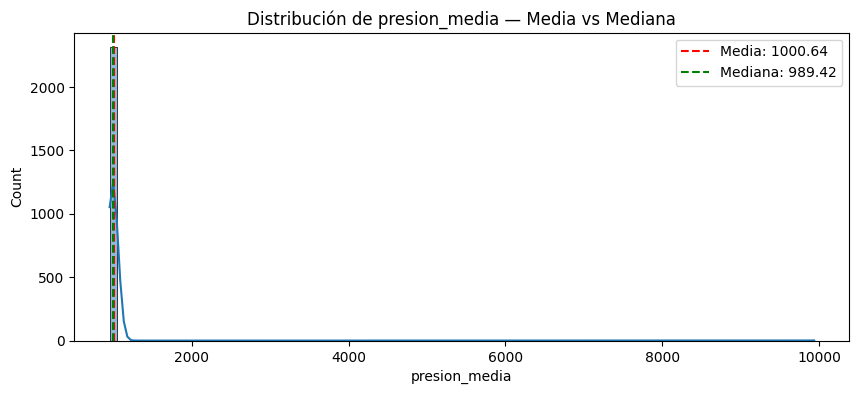

In [76]:
# Comparación media vs mediana en una variable con nulos
col_ejemplo = 'presion_media'

media = data[col_ejemplo].mean()
mediana = data[col_ejemplo].median()

print(f"Media de {col_ejemplo}: {media:.4f}")
print(f"Mediana de {col_ejemplo}: {mediana:.4f}")
print(f"Diferencia: {abs(media - mediana):.4f}")

plt.figure(figsize=(10, 4))
sns.histplot(data[col_ejemplo].dropna(), kde=True)
plt.axvline(media, color='red', linestyle='--', label=f'Media: {media:.2f}')
plt.axvline(mediana, color='green', linestyle='--', label=f'Mediana: {mediana:.2f}')
plt.title(f'Distribución de {col_ejemplo} — Media vs Mediana')
plt.legend()
plt.show()

Si la media y la mediana son similares, la distribución es aproximadamente simétrica y ambas
estrategias imputarían un valor parecido. Si difieren considerablemente, hay asimetría u
outliers residuales que hacen que la mediana sea la opción más robusta (menos sensible a
valores extremos). Como vemos los valores son sumamente similares, por lo cual ambas pueden ser usadas.

**Decisión**: dado que ya corregimos gran parte de los outliers extremos en la etapa de
Validez, ambas estrategias son razonables y viables. Por eso, en lugar de elegir una sola,
se aprovecha esta decisión como uno de los dos ejes de comparación entre los modelos que se
construirán a continuación: **Modelo 1 imputará con mediana** y **Modelo 2 imputará con
media**, permitiendo evaluar empíricamente cuál funciona mejor para este dataset.

La imputación se realiza con `SimpleImputer` de scikit-learn, ajustado **únicamente sobre el
conjunto de entrenamiento** dentro del pipeline — no sobre el dataset completo — para evitar
fuga de datos (*data leakage*), tal como se explicó en la práctica de regresión lineal.

### Partición de los datos (train / test)

Siguiendo las indicaciones del laboratorio, dividimos el conjunto en 75% entrenamiento y 25%
prueba, con semilla fija (`random_state=42`) para garantizar reproducibilidad. Esta división se
hace **antes** de cualquier imputación o escalado, para que esas transformaciones se ajusten
únicamente con los datos de entrenamiento y no haya fuga de información hacia el conjunto de
prueba.

In [77]:
target = 'temp_max_manana'

X = data.drop(columns=[target])
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f"Train: {X_train.shape[0]} registros")
print(f"Test:  {X_test.shape[0]} registros")

Train: 1788 registros
Test:  596 registros


### Construcción de los dos pipelines de preparación y modelado

Se construyen dos pipelines que encapsulan todo el flujo de preparación + modelo, garantizando
que la imputación y el escalado se ajusten solo con `X_train`. Ambos pipelines comparten la
misma estructura general, pero difieren en dos decisiones justificadas en la sección anterior:

| | Pipeline 1 | Pipeline 2 |
|---|---|---|
| Imputación numéricas | Mediana | Media |
| Variable temporal | `mes` (categórica, one-hot) | `dia_del_anio` (numérica continua) |

En ambos se elimina `fecha` (no es predictora directa) y `estacion_anio` (redundante con `mes`
y `dia_del_anio`, generaría colinealidad).

ATENCION: Para la creacion de este texto se uso IAG, pero fue para la generacion de la tabla ya que no sabiamos como crearla.

In [78]:
# Columnas a eliminar en ambas estrategias (no predictoras directas / redundantes)
cols_a_eliminar = ['fecha', 'estacion_anio']

def drop_columns(df, cols=cols_a_eliminar):
    return df.drop(columns=cols, errors='ignore')

dropper = FunctionTransformer(drop_columns)

> **Nota sobre la elección de variables temporales**: se consideró usar `estacion_anio` en
> lugar de `mes` para el Pipeline 1, dado que ambas son categóricas y evitan forzar una relación
> lineal con el ciclo anual. Sin embargo, se mantiene `mes` porque ofrece mayor granularidad
> (12 categorías vs. 4) sin dejar de ser categórica, permitiendo que el modelo aprenda un efecto
> independiente por mes en lugar de agrupar meses completos en una sola estación.

In [79]:
# PIPELINE 1: imputación por MEDIANA + variable temporal categórica (mes) 

numeric_features_1 = [
    'presion_media', 'presion_min', 'presion_max', 'presion_desv',
    'humedad_media', 'humedad_min', 'humedad_max', 'humedad_desv',
    'viento_media', 'viento_min', 'viento_max', 'viento_desv',
    'rafaga_media', 'rafaga_min', 'rafaga_max', 'rafaga_desv',
    'viento_norte', 'viento_este', 'direccion_viento',
    'registros_del_dia', 'anio'
]
categorical_features_1 = ['mes', 'sector_viento']

numeric_transformer_1 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])
categorical_transformer_1 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor_1 = ColumnTransformer(transformers=[
    ('num', numeric_transformer_1, numeric_features_1),
    ('cat', categorical_transformer_1, categorical_features_1),
])

pipeline_1 = Pipeline(steps=[
    ('dropper', dropper),
    ('preprocesamiento', preprocessor_1),
    ('modelo', LinearRegression())
])

In [82]:
# PIPELINE 2: imputación por MEDIA + variable temporal numérica (dia_del_anio) 

numeric_features_2 = numeric_features_1 + ['dia_del_anio']  # se agrega en vez de 'mes'
categorical_features_2 = ['sector_viento']  # ya no incluye mes

numeric_transformer_2 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
])
categorical_transformer_2 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor_2 = ColumnTransformer(transformers=[
    ('num', numeric_transformer_2, numeric_features_2),
    ('cat', categorical_transformer_2, categorical_features_2),
])

pipeline_2 = Pipeline(steps=[
    ('dropper', dropper),
    ('preprocesamiento', preprocessor_2),
    ('modelo', LinearRegression())
])

### Entrenamiento

Entrenamos ambos pipelines completos (preparación + modelo) usando únicamente `X_train`,
`y_train`. Scikit-learn se encarga de que cada paso (imputación, escalado, codificación) se
ajuste solo con estos datos y luego se aplique consistentemente sobre `X_test` cuando se use
`.predict()`.

In [80]:
pipeline_1.fit(X_train, y_train)
print("Pipeline 1 (mediana + mes) entrenado correctamente.")

Pipeline 1 (mediana + mes) entrenado correctamente.


In [83]:
pipeline_2.fit(X_train, y_train)
print("Pipeline 2 (media + dia_del_anio) entrenado correctamente.")

Pipeline 2 (media + dia_del_anio) entrenado correctamente.


Ahora veamos de forma rapida como se ven los pipelines

In [84]:
from sklearn import set_config
set_config(display='diagram')

In [85]:
pipeline_1

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('dropper', ...), ('preprocesamiento', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](26,)","['fecha','presion_media','presion_min',...,'estacion_anio','mes', 'sector_viento']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,26
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function dro...00224BDF9FD80>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False


In [86]:
pipeline_2

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('dropper', ...), ('preprocesamiento', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](26,)","['fecha','presion_media','presion_min',...,'estacion_anio','mes', 'sector_viento']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,26
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function dro...00224BDF9FD80>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False


### Estructura de los pipelines

Los diagramas anteriores confirman que ambos pipelines siguen la misma estructura general
(eliminación de columnas → preprocesamiento por tipo de variable → modelo), pero difieren
exactamente en los dos puntos que planteamos:

- **Pipeline 1**: 21 variables numéricas (imputadas con mediana) + 2 variables categóricas,
  `mes` y `sector_viento` (imputadas por moda y codificadas con One-Hot, generando 20 columnas
  binarias). En total, el modelo recibe 41 variables de entrada.
- **Pipeline 2**: 22 variables numéricas (imputadas con media) — una más que el Pipeline 1,
  porque aquí `dia_del_anio` se trata como numérica en lugar de categórica — y solo 1 variable
  categórica, `sector_viento` (8 columnas binarias). En total, el modelo recibe 30 variables
  de entrada.

Esta diferencia en el número de columnas finales (41 vs. 30) es consecuencia directa de la
decisión tomada: representar el ciclo anual con `mes` como categoría (más columnas, sin asumir
linealidad) frente a representarlo con `dia_del_anio` como número (menos columnas, pero
asumiendo que su efecto

### LO QUE HACE FALTA MI JULIANCHO

Con ambos pipelines ya entrenados, queda pendiente:
1. Generar predicciones sobre train y test para cada modelo (`.predict()`).
2. Calcular RMSE, MAE y R² para ambos, en train y test.
3. Armar la tabla comparativa de métricas.
4. Verificar los supuestos de regresión lineal sobre el mejor modelo (P42).
5. Interpretar los coeficientes / importancia de variables.
6. Generar las predicciones sobre `Datos Test Lab 1.csv` con el mejor modelo.